# Lab 2: Grouping values
## Use mapclassify to create breaks and groups of values (for choropleth map) 

## import libraries and functions 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mapclassify as mc


## basic path joining and loading tabulate data

In [2]:
data_dir = '../datasets/data_dirs/'  # please change to the file location in your directories
os.listdir(data_dir)

['hdb_data_2013.csv.xz', 'hdb_data_2023.csv.xz']

In [3]:
fname = 'hdb_data_2023.csv.xz'  # filename of the file to be red
fp = os.path.join(data_dir, fname)  # join the filename with the location of file
print(fp)  # print to check

df = pd.read_csv(fp, index_col=0)
df.head()  # show the top n rows, n=5 by default

../../datasets/data_dirs/hdb_data_2023.csv.xz


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,2023,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187)
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,2023,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,2023,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)


In [5]:
vs = df['resale_price'].to_list()

<Axes: xlabel='resale_price', ylabel='Count'>

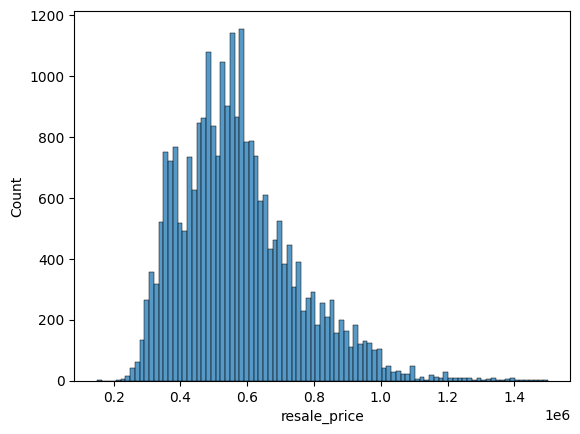

In [6]:
sns.histplot(x='resale_price', data=df, )

In [7]:
breaks = mc.EqualInterval(vs)
breaks

EqualInterval

        Interval           Count
--------------------------------
[ 150000.00,  420000.00] |  5152
( 420000.00,  690000.00] | 15182
( 690000.00,  960000.00] |  4713
( 960000.00, 1230000.00] |   634
(1230000.00, 1500000.00] |    79

In [8]:
breaks.yb

array([0, 0, 0, ..., 2, 2, 3], shape=(25760,))

In [9]:
breaks.bins

array([ 420000.,  690000.,  960000., 1230000., 1500000.])

In [10]:
np.histogram(vs, bins=list(breaks.bins))

(array([15233,  4806,   673,    81]),
 array([ 420000.,  690000.,  960000., 1230000., 1500000.]))

In [11]:
np.histogram(vs, bins=[150000] + [x for x in list(breaks.bins)])

(array([ 4967, 15233,  4806,   673,    81]),
 array([ 150000.,  420000.,  690000.,  960000., 1230000., 1500000.]))

In [12]:
len(vs)

25760

In [13]:
sum([4967, 15233,  4806,   673,    81]) ,sum([5152, 15182,  4713,   634,    79])

(25760, 25760)

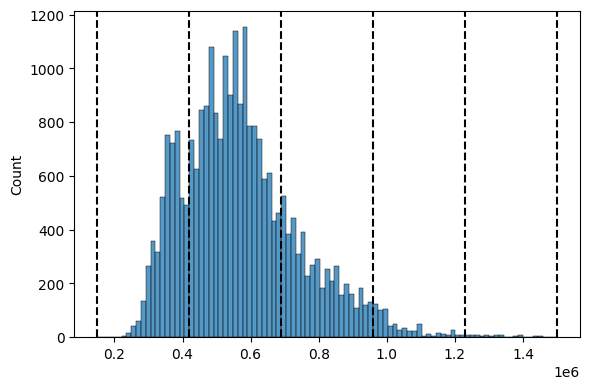

In [14]:
breaks = mc.EqualInterval(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')

plt.tight_layout()

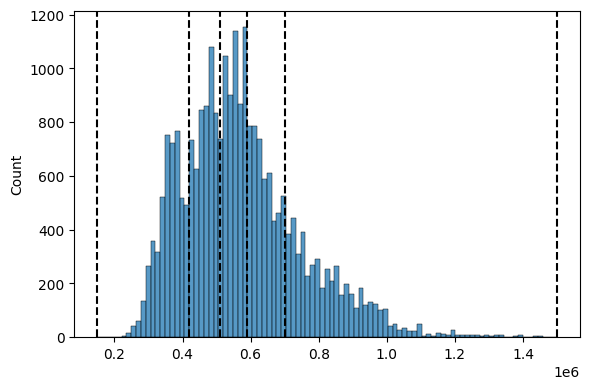

In [15]:
breaks = mc.Quantiles(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

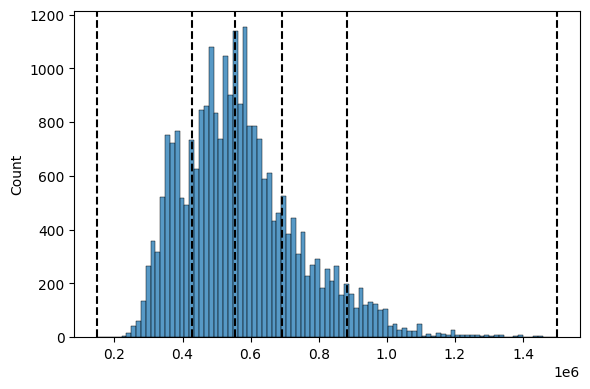

In [16]:
breaks = mc.NaturalBreaks(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

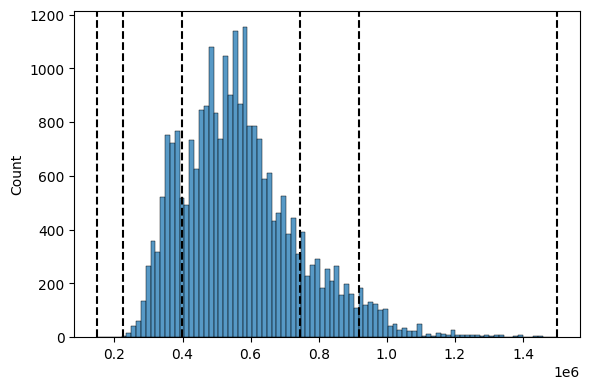

In [17]:
breaks = mc.StdMean(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

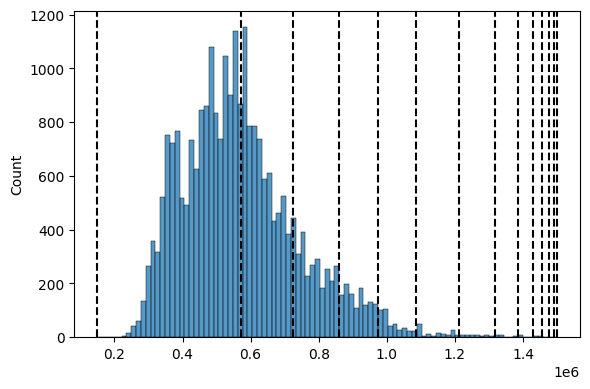

In [18]:
breaks = mc.HeadTailBreaks(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

In [19]:
df['htbreaks_yb'] = breaks.yb

In [20]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry,htbreaks_yb
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,...,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187),0
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,...,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235),0
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,...,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912),0
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,...,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912),0
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,...,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959),0


In [21]:
for g in df['htbreaks_yb'].unique():
    tmp = df[df['htbreaks_yb']==g]
    print(g, len(tmp))


0 14363
1 6903
2 2688
3 1175
4 401
5 139
6 49
7 21
8 11
12 1
11 1
10 2
9 6


<Axes: xlabel='htbreaks_yb', ylabel='resale_price'>

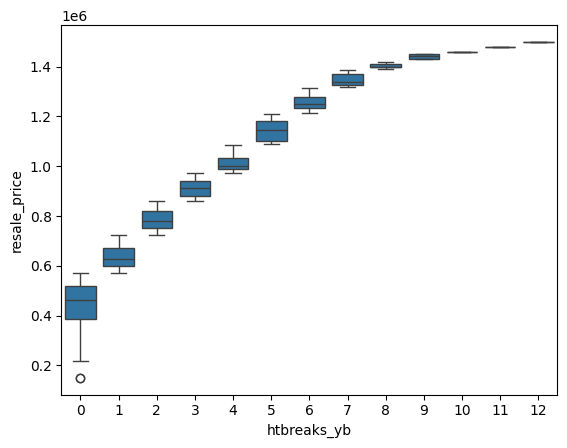

In [22]:
sns.boxplot(x='htbreaks_yb', y='resale_price', data=df)